# Fraud Detection System
**Project 03 — Applied AI Engineering**

This notebook builds a machine learning system that detects fraudulent credit card transactions in real time.

We use a two-layer approach:
1. **Isolation Forest** — an anomaly detection model that learns what normal transactions look like
2. **Logistic Regression** — a classifier that converts the anomaly signal into a clean fraud probability

By the end of this notebook we will have a trained model saved as `fraud_model.pkl` that can be loaded by our FastAPI server and used to score live transactions.

---

## Cell 1 — Imports

Before we do anything we need to load the Python libraries we will use throughout the notebook.

- **pandas** — loads and manipulates our data (think of it as Excel for Python)
- **numpy** — handles numerical operations and arrays
- **matplotlib / seaborn** — creates charts and visualizations
- **sklearn** — scikit-learn, the main ML library. Contains our Isolation Forest, Logistic Regression, and evaluation tools
- **pickle** — saves our trained model to a file so the API can load it later

If this cell prints `All imports OK` we are good to continue.

In [ ]:
# ============================================================
# CELL 1 — Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)
import pickle
import warnings
warnings.filterwarnings('ignore')

print("All imports OK")

All imports OK


## Cell 2 — Load and inspect the data

We load `creditcard.csv` from Kaggle. This is real transaction data from European cardholders over two days in September 2013.

The dataset has **284,807 transactions** and **31 columns**:
- `Time` — seconds elapsed since the first transaction in the dataset
- `V1` to `V28` — anonymized features (explained below)
- `Amount` — transaction value in euros
- `Class` — our target: 0 = legitimate, 1 = fraud

**Why are the features called V1 to V28?**
The bank that provided this data could not share real column names like merchant name or location for privacy reasons. They applied PCA (Principal Component Analysis) which mathematically transforms the original features into anonymous components. V1–V28 are those components. They still carry all the fraud pattern information — they are just anonymized.

In [ ]:
# ============================================================
# CELL 2 — Load & inspect the data
# ============================================================

df = pd.read_csv('creditcard.csv')

print(f"Shape: {df.shape}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean() * 100:.4f}%")
df.head()


Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Cell 3 — Check data quality

Before training any model we always check:
- **Null values** — missing data can break the model or give misleading results
- **Basic stats on Amount and Time** — understanding the range of values helps us decide how to scale them

A good dataset has zero nulls. If we find any we would need to handle them before continuing.

In [ ]:
# ============================================================
# CELL 3 — Check for nulls and basic stats
# ============================================================
print("Null values:", df.isnull().sum().sum())
print("\nBasic stats on Amount and Time:")
print(df[['Time', 'Amount']].describe())


Null values: 0

Basic stats on Amount and Time:
                Time         Amount
count  284807.000000  284807.000000
mean    94813.859575      88.349619
std     47488.145955     250.120109
min         0.000000       0.000000
25%     54201.500000       5.600000
50%     84692.000000      22.000000
75%    139320.500000      77.165000
max    172792.000000   25691.160000


## Cell 4 — Visualize the class imbalance

This chart reveals the core challenge of this problem.

**The left chart** shows the class distribution — there are roughly 284,000 legitimate transactions and only 492 fraud cases. That is a 577:1 ratio. This is called **class imbalance** and it is why we cannot use accuracy as our metric. A model that just predicts everything as legitimate would be 99.83% accurate and completely useless.

**The right chart** shows transaction amounts by class. Notice how fraud transactions tend to cluster at different amounts compared to legitimate ones — this is a pattern the model can learn.

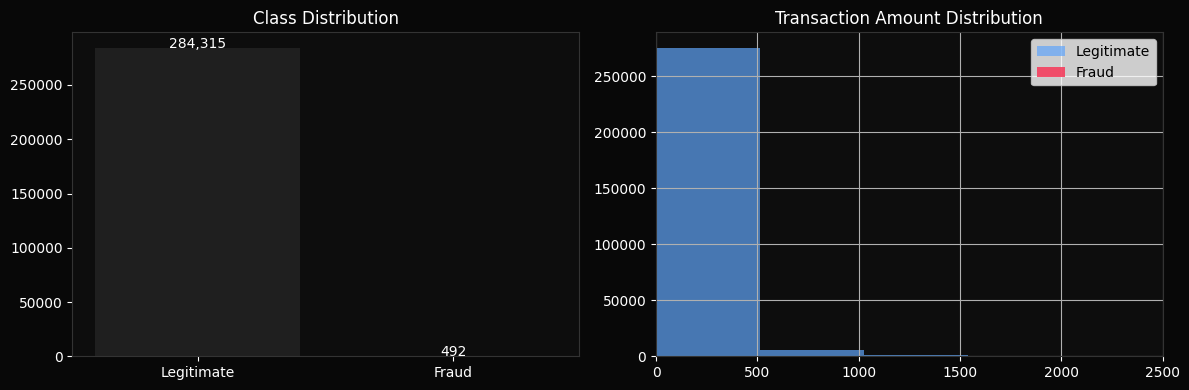

In [ ]:
# ============================================================
# CELL 4 — Visualise class imbalance
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
counts = df['Class'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], counts.values, color=['#1f1f1f', '#f43f5e'])
axes[0].set_title('Class Distribution', color='white')
axes[0].set_facecolor('#0d0d0d')
axes[0].tick_params(colors='white')
for spine in axes[0].spines.values():
    spine.set_edgecolor('#333')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', color='white', fontsize=10)

# Transaction amount by class
df[df['Class'] == 0]['Amount'].hist(
    ax=axes[1], bins=50, alpha=0.7, color='#60a5fa', label='Legitimate'
)
df[df['Class'] == 1]['Amount'].hist(
    ax=axes[1], bins=50, alpha=0.9, color='#f43f5e', label='Fraud'
)
axes[1].set_title('Transaction Amount Distribution', color='white')
axes[1].set_facecolor('#0d0d0d')
axes[1].tick_params(colors='white')
axes[1].legend()
axes[1].set_xlim(0, 2500)
for spine in axes[1].spines.values():
    spine.set_edgecolor('#333')

fig.patch.set_facecolor('#080808')
plt.tight_layout()
plt.show()


## Cell 5 — Feature engineering and scaling

**Why do we scale Amount and Time?**

Machine learning models are sensitive to the size of numbers. `Amount` ranges from €0 to €25,000. The V1–V28 features are already small decimals between roughly -5 and +5 because PCA standardized them.

If we leave `Amount` unscaled, the model treats it as far more important just because the number is bigger — even if that is not statistically true. Scaling puts every feature on the same playing field.

We use `StandardScaler` which transforms values to have a mean of 0 and standard deviation of 1. After scaling, a transaction of €25,000 becomes roughly +98 in standardized units — still unusual, but now comparable to V1–V28.

In [ ]:
# ============================================================
# CELL 5 — Feature engineering & scaling
# ============================================================
# Scale Amount and Time (V1-V28 are already PCA-transformed)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Drop originals
df_model = df.drop(['Time', 'Amount'], axis=1)

# Features and target
feature_cols = [c for c in df_model.columns if c != 'Class']
X = df_model[feature_cols]
y = df_model['Class']

print(f"Features: {len(feature_cols)}")
print(f"X shape: {X.shape}")
print(f"Fraud cases: {y.sum()} / {len(y)}")

Features: 30
X shape: (284807, 30)
Fraud cases: 492 / 284807


## Cell 6 — Train / test split

We split the data into two sets:
- **Training set (80%)** — the model learns from this data
- **Test set (20%)** — we evaluate the model on data it has never seen

This is important because we need to know if the model generalizes to new transactions, not just memorizes the training data.

**Why `stratify=y`?**
Only 0.17% of transactions are fraud. If we split randomly, we might end up with zero fraud cases in our test set by pure chance — making evaluation meaningless. `stratify=y` guarantees both sets maintain the same fraud ratio.

In [ ]:
# ============================================================
# CELL 6 — Train / test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keep fraud ratio consistent
)

print(f"Train size: {len(X_train):,}")
print(f"Test size:  {len(X_test):,}")
print(f"Train fraud cases: {y_train.sum()}")
print(f"Test fraud cases:  {y_test.sum()}")


Train size: 227,845
Test size:  56,962
Train fraud cases: 394
Test fraud cases:  98


## Cell 7 — Train Isolation Forest

**What is Isolation Forest?**

Imagine a forest of random decision trees. Each tree randomly picks a feature and a split point, over and over, until each transaction is isolated in its own leaf. Normal transactions blend in with others and take many splits to isolate. Unusual transactions — fraud — stand out and get isolated much faster.

The fewer splits needed to isolate a transaction, the higher its anomaly score.

**Why train only on legitimate transactions?**

This is the key insight. We want the model to learn what normal looks like. If we train on fraud too, it learns fraud as normal and stops flagging it. By hiding fraud during training, the model discovers fraud as transactions that do not fit the normal pattern it learned.

In [ ]:
# ============================================================
# CELL 7 — Train Isolation Forest
# ============================================================
# contamination = approx fraud rate in dataset
fraud_rate = y_train.mean()
print(f"Setting contamination to: {fraud_rate:.5f}")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=fraud_rate,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train[y_train == 0])  # train only on legit transactions
print("Isolation Forest trained.")


Setting contamination to: 0.00173
Isolation Forest trained.


## Cell 8 — Get anomaly scores

`score_samples()` returns a negative value for each transaction. More negative = more anomalous = more likely fraud.

We flip the sign (multiply by -1) so higher values mean more suspicious. Then we normalize to a 0–1 range using MinMaxScaler so the scores are easier to work with and compare.

This normalized anomaly score becomes an extra feature that we pass to the Logistic Regression model in the next step.

In [ ]:
# ============================================================
# CELL 8 — Get anomaly scores from Isolation Forest
# ============================================================
# score_samples returns negative values — more negative = more anomalous
iso_scores_train = -iso_forest.score_samples(X_train)
iso_scores_test  = -iso_forest.score_samples(X_test)

# Normalise to 0-1 range
from sklearn.preprocessing import MinMaxScaler
score_scaler = MinMaxScaler()
iso_scores_train_norm = score_scaler.fit_transform(iso_scores_train.reshape(-1, 1)).flatten()
iso_scores_test_norm  = score_scaler.transform(iso_scores_test.reshape(-1, 1)).flatten()

print(f"Sample anomaly scores (test): {iso_scores_test_norm[:5]}")


Sample anomaly scores (test): [0.10968539 0.30307264 0.53644067 0.01889742 0.26416434]


## Cell 9 — Train Logistic Regression on top

**Why do we need a second model?**

Isolation Forest gives us an anomaly score — a raw measure of how unusual a transaction is. But unusual does not always mean fraudulent. A very large legitimate purchase is unusual but not fraud.

Logistic Regression takes the anomaly score AND all the original features and learns the relationship between them and the actual fraud labels. It outputs a clean probability between 0 and 1 — something a real fraud system can act on.

**Why `class_weight='balanced'`?**
Because fraud is so rare, we tell the model to pay extra attention to fraud cases during training. Without this, the model might learn to ignore fraud entirely because it is so infrequent.

In [ ]:
# ============================================================
# CELL 9 — Train Logistic Regression on top of anomaly scores
# ============================================================
# Stack anomaly score with original features for a stronger model
X_train_lr = np.column_stack([X_train, iso_scores_train_norm])
X_test_lr  = np.column_stack([X_test, iso_scores_test_norm])

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_lr, y_train)
print("Logistic Regression trained on top of anomaly scores.")

## Cell 10 — Evaluate the model

**Why not use accuracy?**
A model that predicts every transaction as legitimate would be 99.83% accurate and catch zero fraud. Accuracy is meaningless on imbalanced data.

**ROC-AUC** measures how well the model separates fraud from legitimate across all possible decision thresholds. 1.0 = perfect, 0.5 = random guessing. Anything above 0.95 on this dataset is genuinely strong.

**Average Precision** measures the area under the Precision-Recall curve. Especially useful on imbalanced datasets — it tells you how well the model performs specifically on the rare fraud class.

In [ ]:
# ============================================================
# CELL 10 — Evaluate the model
# ============================================================
y_pred = lr_model.predict(X_test_lr)
y_prob = lr_model.predict_proba(X_test_lr)[:, 1]

print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

roc_auc = roc_auc_score(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)
print(f"ROC-AUC Score:        {roc_auc:.4f}")
print(f"Average Precision:    {avg_precision:.4f}")




## Cell 11 — Confusion matrix

The confusion matrix shows us four things:

| | Predicted Legit | Predicted Fraud |
|---|---|---|
| **Actually Legit** | True Negative ✓ | False Positive ✗ |
| **Actually Fraud** | False Negative ✗ | True Positive ✓ |

- **True Negatives** — legitimate transactions correctly cleared (good)
- **True Positives** — fraud correctly caught (good)
- **False Positives** — legitimate transactions blocked (bad — frustrated customers)
- **False Negatives** — fraud that slipped through (bad — financial loss)

In fraud detection, False Negatives are usually more costly than False Positives.

In [ ]:
# ============================================================
# CELL 11 — Confusion matrix
# ============================================================
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Reds',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud'],
    ax=ax,
    linewidths=0.5
)
ax.set_title('Confusion Matrix', color='white', pad=12)
ax.set_xlabel('Predicted', color='white')
ax.set_ylabel('Actual', color='white')
ax.tick_params(colors='white')
ax.set_facecolor('#0d0d0d')
fig.patch.set_facecolor('#080808')
plt.tight_layout()
plt.show()




## Cell 12 — Precision-Recall curve

**Precision** = of all transactions we flagged as fraud, what percentage actually were fraud?

**Recall** = of all actual fraud transactions, what percentage did we catch?

There is always a tradeoff. If we flag everything as fraud (recall = 100%) we will also block thousands of innocent customers (precision = very low). The curve shows us this tradeoff at every possible threshold so we can pick the right operating point.

A higher area under this curve = better model overall.

In [ ]:
# ============================================================
# CELL 12 — Precision-Recall curve
# ============================================================
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(recall, precision, color='#f43f5e', linewidth=2, label=f'AP = {avg_precision:.3f}')
ax.fill_between(recall, precision, alpha=0.1, color='#f43f5e')
ax.set_xlabel('Recall', color='white')
ax.set_ylabel('Precision', color='white')
ax.set_title('Precision-Recall Curve', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white')
ax.set_facecolor('#0d0d0d')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#333')
fig.patch.set_facecolor('#080808')
plt.tight_layout()
plt.show()




## Cell 13 — Save the model

We save everything the API needs into a single `fraud_model.pkl` file using `pickle`.

Think of `pickle` as zipping up the trained model and putting it in a box. Later our FastAPI server opens that box, takes out the model, and uses it to score new transactions without having to retrain from scratch.

We save:
- `iso_forest` — the trained Isolation Forest
- `lr_model` — the trained Logistic Regression
- `score_scaler` — the MinMaxScaler (needed to normalize anomaly scores the same way during prediction)
- `feature_cols` — the list of feature names in the correct order
- `roc_auc` and `avg_precision` — model stats displayed on the portfolio site

In [ ]:
# ============================================================
# CELL 13 — Save everything needed for the API
# ============================================================
model_artifacts = {
    'iso_forest': iso_forest,
    'lr_model': lr_model,
    'score_scaler': score_scaler,
    'feature_cols': feature_cols,
    'roc_auc': round(roc_auc, 4),
    'avg_precision': round(avg_precision, 4),
}

with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print("Model saved to fraud_model.pkl")
print(f"\nModel stats:")
print(f"  ROC-AUC:          {roc_auc:.4f}")
print(f"  Avg Precision:    {avg_precision:.4f}")
print(f"  Features used:    {len(feature_cols)}")




## Cell 14 — Sanity check

Before we trust this model with real predictions, we do a final sanity check.

We load the saved `.pkl` file (simulating what the API does) and feed it two known transactions:
1. A **known fraud case** from the test set — should return a HIGH probability
2. A **known legitimate case** from the test set — should return a LOW probability

If fraud probability >> legit probability, our model and our save/load pipeline are both working correctly.

In [ ]:
# ============================================================
# CELL 14 — Quick sanity check (test a prediction manually)
# ============================================================
with open('fraud_model.pkl', 'rb') as f:
    artifacts = pickle.load(f)

# Take one real fraud case from test set
fraud_sample = X_test[y_test == 1].iloc[0:1]
fraud_score_raw = -artifacts['iso_forest'].score_samples(fraud_sample)
fraud_score_norm = artifacts['score_scaler'].transform(fraud_score_raw.reshape(-1, 1))
fraud_input = np.column_stack([fraud_sample, fraud_score_norm])
fraud_prob = artifacts['lr_model'].predict_proba(fraud_input)[0][1]

# Take one real legit case
legit_sample = X_test[y_test == 0].iloc[0:1]
legit_score_raw = -artifacts['iso_forest'].score_samples(legit_sample)
legit_score_norm = artifacts['score_scaler'].transform(legit_score_raw.reshape(-1, 1))
legit_input = np.column_stack([legit_sample, legit_score_norm])
legit_prob = artifacts['lr_model'].predict_proba(legit_input)[0][1]

print("Sanity check:")
print(f"  Known fraud transaction  → fraud probability: {fraud_prob:.4f}")
print(f"  Known legit transaction  → fraud probability: {legit_prob:.4f}")
print("\nModel is working correctly if fraud >> legit above.")

---
## Done

`fraud_model.pkl` is now saved in this folder and ready to be loaded by the FastAPI server in `api.py`.

**Next step:** Run `uvicorn api:app --reload` in your terminal to start the API server, then open `http://localhost:8000/docs` to test live predictions.